<a href="https://colab.research.google.com/github/mjcolebank/Colebank_REU_2026/blob/main/Colebank_100K_Folder/VanillaBCNN_Optimized_cleaner_100K.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Uncomment this line if Pyro is not installed.
#%pip install pyro-ppl torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 11.0 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/REU ECG Analysis
!ls

Mounted at /content/drive
/content/drive/.shortcut-targets-by-id/1R0Rm_tQkPv4BMW6L3PT9j80xpPsVEffJ/REU ECG Analysis
 BCNN		        EchonextBigData
 CNN		        EchoNext_EchoData_5K.csv
'CNN Models ALL.gdoc'  'Project Summary.gdoc'
 ECG_metrics_1K.npy    'TripleCNN Model Overview (Pooling Methods).gdoc'
 ECG_waveforms_1K.npy


Using device: cuda

Split sizes -> train: 720, val: 180, test: 100
Beginning execution pipeline...
Training model...

===== Individual Test Sample Inference Profiles ====
Sample 000 (DF Index: 477) | True: 1 | Pred: 1 | Confidence: 0.8968 | Uncertainty (Std): 0.1908
Sample 001 (DF Index: 837) | True: 1 | Pred: 1 | Confidence: 0.9858 | Uncertainty (Std): 0.0888
Sample 002 (DF Index: 302) | True: 1 | Pred: 1 | Confidence: 0.8282 | Uncertainty (Std): 0.2606
Sample 003 (DF Index: 405) | True: 0 | Pred: 0 | Confidence: 0.5320 | Uncertainty (Std): 0.2892
Sample 004 (DF Index: 333) | True: 1 | Pred: 1 | Confidence: 0.8445 | Uncertainty (Std): 0.2072
Sample 005 (DF Index: 332) | True: 1 | Pred: 1 | Confidence: 0.7757 | Uncertainty (Std): 0.2081
Sample 006 (DF Index: 886) | True: 0 | Pred: 0 | Confidence: 0.8433 | Uncertainty (Std): 0.2759
Sample 007 (DF Index: 730) | True: 0 | Pred: 0 | Confidence: 0.6527 | Uncertainty (Std): 0.1996
Sample 008 (DF Index: 775) | True: 0 | Pred: 1 | Confidence: 

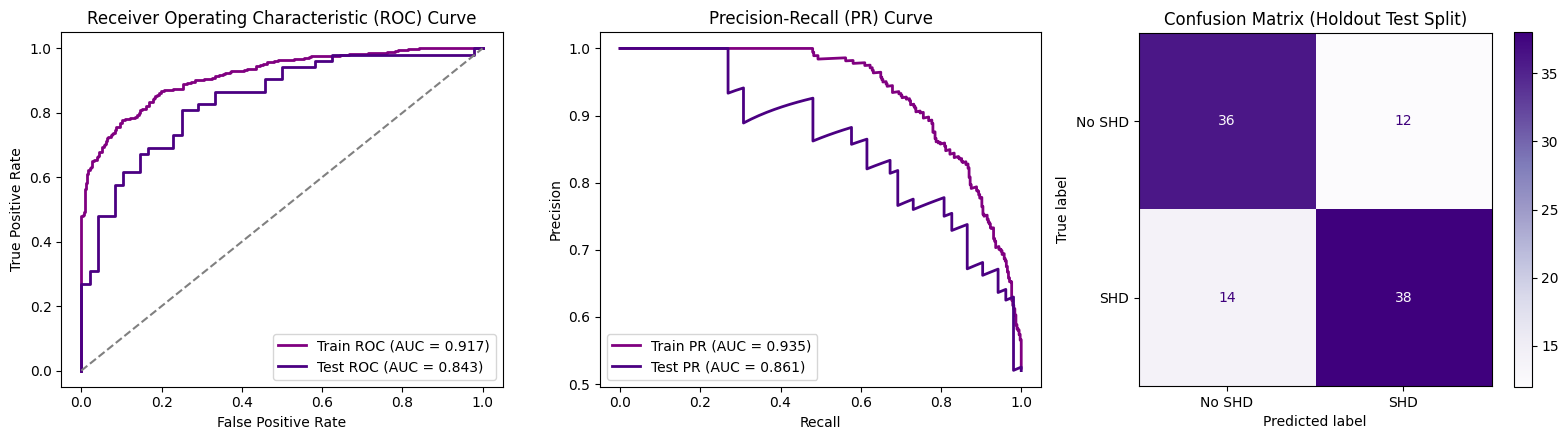

In [ ]:
import math
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, Predictive
from pyro.infer.autoguide import AutoDiagonalNormal
from pyro.nn import PyroModule, PyroSample
from pyro.optim import Adam
from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    auc,
    roc_curve,
    brier_score_loss,
    ConfusionMatrixDisplay
)
from scipy.signal import butter, filtfilt

# ──────────────────────────────────────────────────────────────────────
# 0. CONFIGURATION & HYPERPARAMETERS
# ──────────────────────────────────────────────────────────────────────
RANDOM_SEED = 42

def set_seed(seed=RANDOM_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(RANDOM_SEED)
pyro.set_rng_seed(RANDOM_SEED)
pyro.clear_param_store()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ──────────────────────────────────────────────────────────────────────
# 1. SIGNAL PROCESSING & SIGNAL FILTERING
# ──────────────────────────────────────────────────────────────────────
ECG_SAMPLING_RATE_HZ = 250   # Matches EchoNext waveform acquisition rate
FILTER_LOW_HZ = 0.5          # Removes baseline wander
FILTER_HIGH_HZ = 40.0        # Removes high-frequency EMG / powerline noise
FILTER_ORDER = 4

def bandpass_filter_ecg(signal_array, fs=ECG_SAMPLING_RATE_HZ,
                         low=FILTER_LOW_HZ, high=FILTER_HIGH_HZ, order=FILTER_ORDER):
    nyquist = 0.5 * fs
    b, a = butter(order, [low / nyquist, high / nyquist], btype="band")
    filtered = filtfilt(b, a, signal_array, axis=0)  # Time is axis 0 for a single [L, C] sample
    return filtered.astype(np.float32)

# ──────────────────────────────────────────────────────────────────────
# 2. DATA INGESTION & TENSOR CONVERSION (100K PIPELINE INTEGRATION)
# ──────────────────────────────────────────────────────────────────────
print("Loading 100K data splits...")
# Loading the explicit train, validation, and test numpy arrays from the 100K architecture
ECG_train_raw = np.load('../EchoNextData/EchoNext_train_waveforms.npy')
ECG_val_raw   = np.load('../EchoNextData/EchoNext_val_waveforms.npy')
ECG_test_raw  = np.load('../EchoNextData/EchoNext_test_waveforms.npy')
Echo_data     = pd.read_csv('../EchoNextData/echonext_metadata_100k.csv')

# Pull out index values based on pre-defined splits
train_ids = Echo_data.index[Echo_data['split'] == 'train'].tolist()
val_ids   = Echo_data.index[Echo_data['split'] == 'val'].tolist()
test_ids  = Echo_data.index[Echo_data['split'] == 'test'].tolist()

y_train = np.array(Echo_data['shd_moderate_or_greater_flag'][train_ids])
y_val   = np.array(Echo_data['shd_moderate_or_greater_flag'][val_ids])
y_test  = np.array(Echo_data['shd_moderate_or_greater_flag'][test_ids])

# Extracting lead 1 records
X_train_lead1 = ECG_train_raw[:, 0, :, :]
X_val_lead1   = ECG_val_raw[:, 0, :, :]
X_test_lead1  = ECG_test_raw[:, 0, :, :]

print("Applying bandpass filtering to waveforms...")
X_filt_train = np.array([bandpass_filter_ecg(x, fs=ECG_SAMPLING_RATE_HZ) for x in X_train_lead1])
X_filt_val   = np.array([bandpass_filter_ecg(x, fs=ECG_SAMPLING_RATE_HZ) for x in X_val_lead1])
X_filt_test  = np.array([bandpass_filter_ecg(x, fs=ECG_SAMPLING_RATE_HZ) for x in X_test_lead1])

# Convert shapes to format: [N, channels, sequence_length]
X_ts_train = np.swapaxes(X_filt_train, 1, 2)
X_ts_val   = np.swapaxes(X_filt_val, 1, 2)
X_ts_test  = np.swapaxes(X_filt_test, 1, 2)

print(f"Split sizes -> train: {len(train_ids)}, val: {len(val_ids)}, test: {len(test_ids)}")

def make_loader(X_arr, y_arr, batch_size, shuffle):
    X_t = torch.tensor(X_arr, dtype=torch.float32)
    y_t = torch.tensor(y_arr, dtype=torch.long)
    dataset = TensorDataset(X_t, y_t)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

# Build data loaders from the partitioned datasets (Keeping fixed ordered tracks for profiling)
ts_train_loader = make_loader(X_ts_train, y_train, batch_size=32, shuffle=False)
ts_val_loader   = make_loader(X_ts_val,   y_val,   batch_size=128, shuffle=False)
ts_test_loader  = make_loader(X_ts_test,  y_test,  batch_size=128, shuffle=False)

# ──────────────────────────────────────────────────────────────────────
# 3. BAYESIAN SMALL CNN ARCHITECTURE (UNFUSED BCNN TARGET)
# ──────────────────────────────────────────────────────────────────────
class BayesianSmallCNN(PyroModule):
    def __init__(self, in_channels=12, prior_scale=2.0, pooled_len=1):
        super().__init__()
        self.pooled_len = pooled_len
        self.prior_scale = prior_scale
        self.register_buffer("_device_anchor", torch.tensor(0.0))

        def make_prior(shape):
            def prior(_module):
                dev = self._device_anchor.device
                loc = torch.tensor(0.0, device=dev)
                scale = torch.tensor(prior_scale, device=dev)
                return dist.Normal(loc, scale).expand(shape).to_event(len(shape))
            return prior

        conv1_out, conv1_k, conv1_pad = 50, 51, 1
        hidden_out, hidden_k, hidden_pad = 31, 21, 1

        def make_bayesian_conv(in_ch, out_ch, kernel_size, padding):
            layer = PyroModule[nn.Conv1d](in_ch, out_ch, kernel_size=kernel_size, padding=padding)
            layer.weight = PyroSample(make_prior([out_ch, in_ch, kernel_size]))
            layer.bias = PyroSample(make_prior([out_ch]))
            return layer

        self.conv1 = make_bayesian_conv(in_channels, conv1_out, conv1_k, conv1_pad)
        self.conv2 = make_bayesian_conv(conv1_out, hidden_out, hidden_k, hidden_pad)
        self.conv3 = make_bayesian_conv(hidden_out, hidden_out, hidden_k, hidden_pad)
        self.conv4 = make_bayesian_conv(hidden_out, hidden_out, hidden_k, hidden_pad)

        self.bn1 = nn.BatchNorm1d(conv1_out)
        self.bn2 = nn.BatchNorm1d(hidden_out)
        self.bn3 = nn.BatchNorm1d(hidden_out)
        self.bn4 = nn.BatchNorm1d(hidden_out)

        self.fc1 = PyroModule[nn.Linear](hidden_out, 32)
        self.fc1.weight = PyroSample(make_prior([32, hidden_out]))
        self.fc1.bias = PyroSample(make_prior([32]))

        self.fc2 = PyroModule[nn.Linear](32, 2)
        self.fc2.weight = PyroSample(make_prior([2, 32]))
        self.fc2.bias = PyroSample(make_prior([2]))

    def forward(self, x, y=None, dataset_size=None):
        x = x.to(self._device_anchor.device)
        if y is not None:
            y = y.to(self._device_anchor.device)

        x = F.relu(self.bn1(self.conv1(x)))
        x = F.max_pool1d(x, kernel_size=2)
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.max_pool1d(x, kernel_size=2)
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.max_pool1d(x, kernel_size=2)
        x = F.relu(self.bn4(self.conv4(x)))
        x = F.max_pool1d(x, kernel_size=2)

        x = F.adaptive_avg_pool1d(x, 1)
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.fc1(x))
        logits = self.fc2(x)

        if y is not None and dataset_size is not None:
            scale = dataset_size / x.shape[0]
        else:
            scale = 1.0

        with pyro.plate("data", x.shape[0]):
            with pyro.poutine.scale(scale=scale):
                pyro.sample("obs", dist.Categorical(logits=logits), obs=y)

        return logits

# ──────────────────────────────────────────────────────────────────────
# 4. TRAINING PIPELINE (SVI LOOP WITH VALIDATION METRICS PRINTING)
# ──────────────────────────────────────────────────────────────────────
# dynamically map target channel configurations based on the loaded datasets
bcnn = BayesianSmallCNN(in_channels=X_ts_train.shape[1], prior_scale=2.0).to(device)
bcnn_guide = AutoDiagonalNormal(bcnn)
bcnn_optimizer = Adam({"lr": 1e-4, "betas": (0.9, 0.999)})
bcnn_svi = SVI(model=bcnn, guide=bcnn_guide, optim=bcnn_optimizer, loss=Trace_ELBO())

def train_one_epoch_svi(svi, data_loader, device, dataset_size):
    bcnn.train()
    total_loss = 0.0
    total_examples = 0
    for x, y in data_loader:
        x, y = x.to(device), y.to(device)
        # Random noise data augmentation structure matched from the 100K notebook configuration
        x += 0.05 * torch.randn_like(x)
        loss = svi.step(x, y, dataset_size)
        total_loss += loss
        total_examples += x.shape[0]
    return total_loss / max(1, total_examples)

@torch.no_grad()
def evaluate_validation_loss(model, guide, val_loader, device):
    model.eval()
    elbo = Trace_ELBO()
    total_nll = 0.0
    total_examples = 0

    for x, y in val_loader:
        x_dev, y_dev = x.to(device), y.to(device)
        loss = elbo.differentiable_loss(model, guide, x_dev, y_dev, x_dev.shape[0])
        total_nll += float(loss.detach().cpu())
        total_examples += x_dev.shape[0]

    return total_nll / max(total_examples, 1)

# ──────────────────────────────────────────────────────────────────────
# 5. PERFORMANCE METRICS GENERATION & CALIBRATION ESTIMATION
# ──────────────────────────────────────────────────────────────────────
def calculate_calibration_error(probs, labels, bins=10):
    bin_boundaries = np.linspace(0, 1, bins + 1)
    ece = 0.0
    for i in range(bins):
        bin_lower, bin_upper = bin_boundaries[i], bin_boundaries[i + 1]
        in_bin = (probs >= bin_lower) & (probs < bin_upper)
        prop_in_bin = np.mean(in_bin)
        if prop_in_bin > 0:
            accuracy_in_bin = np.mean(labels[in_bin] == (probs[in_bin] >= 0.5))
            avg_confidence_in_bin = np.mean(probs[in_bin])
            ece += prop_in_bin * np.abs(avg_confidence_in_bin - accuracy_in_bin)
    return ece

@torch.no_grad()
def get_predictions_and_labels_bayesian(model, guide, loader, num_samples=50):
    model.eval()
    all_probs, all_labels = [], []

    elbo = Trace_ELBO()
    total_nll = 0.0
    total_examples = 0

    for x, y in loader:
        x_dev, y_dev = x.to(device), y.to(device)

        predictive = Predictive(model, guide=guide, num_samples=num_samples, return_sites=('_RETURN',))
        out = predictive(x_dev, None)
        logits_samples = out["_RETURN"]
        probs_samples = torch.softmax(logits_samples, dim=-1)
        mean_probs = probs_samples.mean(dim=0)

        loss = elbo.differentiable_loss(model, guide, x_dev, y_dev, x_dev.shape[0])
        total_nll += float(loss.detach().cpu())
        total_examples += x_dev.shape[0]

        all_probs.extend(mean_probs[:, 1].cpu().numpy())
        all_labels.extend(y.numpy())

    return np.array(all_probs), np.array(all_labels), total_nll / max(total_examples, 1)

def generate_and_display_comparative_metrics(model, guide, train_loader, test_loader, num_samples=50):
    train_probs, train_labels, train_nll = get_predictions_and_labels_bayesian(model, guide, train_loader, num_samples)
    test_probs, test_labels, test_nll = get_predictions_and_labels_bayesian(model, guide, test_loader, num_samples)

    train_preds = (train_probs >= 0.5).astype(int)
    test_preds = (test_probs >= 0.5).astype(int)

    metrics_map = {
        "accuracy": (np.mean(train_preds == train_labels), np.mean(test_preds == test_labels)),
        "auroc": (roc_auc_score(train_labels, train_probs), roc_auc_score(test_labels, test_probs)),
        "auprc": (None, None),
        "brier_score": (brier_score_loss(train_labels, train_probs), brier_score_loss(test_labels, test_probs)),
        "negative_log_likelihood": (train_nll, test_nll),
        "expected_calibration_error": (calculate_calibration_error(train_probs, train_labels), calculate_calibration_error(test_probs, test_labels))
    }

    train_precision, train_recall, _ = precision_recall_curve(train_labels, train_probs)
    train_fpr, train_tpr, _ = roc_curve(train_labels, train_probs)
    metrics_map["auprc"] = (auc(train_recall, train_precision), metrics_map["auprc"][1])

    test_precision, test_recall, _ = precision_recall_curve(test_labels, test_probs)
    test_fpr, test_tpr, _ = roc_curve(test_labels, test_probs)
    metrics_map["auprc"] = (metrics_map["auprc"][0], auc(test_recall, test_precision))

    tn_tr, fp_tr, fn_tr, tp_tr = confusion_matrix(train_labels, train_preds).ravel()
    tn_te, fp_te, fn_te, tp_te = confusion_matrix(test_labels, test_preds).ravel()

    metrics_map["tn"] = (float(tn_tr), float(tn_te))
    metrics_map["fp"] = (float(fp_tr), float(fp_te))
    metrics_map["fn"] = (float(fn_tr), float(fn_te))
    metrics_map["tp"] = (float(tp_tr), float(tp_te))

    # ── PRINT EXACT ALIGNED TEXT TABLE ──
    print("==================================================")
    print("Classification metrics (train vs. test):")
    print(f"{'':<28} {'train':<10} {'test':<10}")
    print("--------------------------------------------------")
    for k, v in metrics_map.items():
        print(f"{k:<28} {v[0]:.6f}   {v[1]:.6f}")
    print("==================================================")

    # ── PLOT ANALYSIS GRAPH PROFILES (Updated palette configurations) ──
    fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))

    # 1. ROC Curves
    ax[0].plot(train_fpr, train_tpr, color='teal', lw=2, label=f'Train ROC (AUC = {metrics_map["auroc"][0]:.3f})')
    ax[0].plot(test_fpr, test_tpr, color='orange', lw=2, label=f'Test ROC (AUC = {metrics_map["auroc"][1]:.3f})')
    ax[0].plot([0, 1], [0, 1], color='navy', linestyle='--')
    ax[0].set_xlabel('False Positive Rate')
    ax[0].set_ylabel('True Positive Rate')
    ax[0].set_title('Receiver Operating Characteristic (ROC) Curve')
    ax[0].legend(loc='lower right')

    # 2. Precision-Recall Curves
    ax[1].plot(train_recall, train_precision, color='teal', lw=2, label=f'Train PR (AUC = {metrics_map["auprc"][0]:.3f})')
    ax[1].plot(test_recall, test_precision, color='orange', lw=2, label=f'Test PR (AUC = {metrics_map["auprc"][1]:.3f})')
    ax[1].set_xlabel('Recall')
    ax[1].set_ylabel('Precision')
    ax[1].set_title('Precision-Recall (PR) Curve')
    ax[1].legend(loc='lower left')

    # 3. Consolidated Confusion Matrix (Test Split)
    cm_test = confusion_matrix(test_labels, test_preds)
    ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=["No SHD", "SHD"]).plot(ax=ax[2], cmap="Blues", values_format="d")
    ax[2].set_title("Confusion Matrix (Holdout Test Split)")

    plt.tight_layout()
    plt.show()

# ──────────────────────────────────────────────────────────────────────
# 6. EXECUTION PIPELINE
# ──────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    print("Beginning execution pipeline...")

    num_epochs = 60
    print("Training model...")

    for epoch in range(num_epochs):
        avg_train_loss = train_one_epoch_svi(
            bcnn_svi,
            ts_train_loader,
            device,
            dataset_size=len(train_ids)
        )
        avg_val_loss = evaluate_validation_loss(bcnn, bcnn_guide, ts_val_loader, device)
        print(f"Epoch {epoch+1:02d}/{num_epochs:02d} | Train Loss: {avg_train_loss:.4f} | Dedicated Validation Loss: {avg_val_loss:.6f}")

    # Reset seed right before inference testing to preserve precise sampling behavior
    torch.manual_seed(RANDOM_SEED)

    # ── PRINT SAMPLE INDIVIDUAL INFERENCE RECORDS ─────────────
    print("\n===== Individual Test Sample Inference Profiles ====")
    bcnn.eval()
    sample_counter = 0

    with torch.no_grad():
        for x, y in ts_test_loader:
            x_dev = x.to(device)
            predictive = Predictive(bcnn, guide=bcnn_guide, num_samples=50, return_sites=('_RETURN',))
            out = predictive(x_dev, None)
            logits_samples = out["_RETURN"]
            probs_samples = torch.softmax(logits_samples, dim=-1)
            mean_probs = probs_samples.mean(dim=0).cpu().numpy()
            std_probs = probs_samples.std(dim=0).cpu().numpy()

            for idx in range(x.size(0)):
                true_val = y[idx].item()
                pred_val = np.argmax(mean_probs[idx])
                confidence = mean_probs[idx][pred_val]
                uncertainty = std_probs[idx][pred_val]
                global_df_idx = test_ids[sample_counter] # Get original index matched to 100K arrays

                print(f"Sample {sample_counter:03d} (DF Index: {global_df_idx:03d}) | True: {true_val} | Pred: {pred_val} | "
                      f"Confidence: {confidence:.4f} | Uncertainty (Std): {uncertainty:.4f}")
                sample_counter += 1

    # ── SYSTEM METRICS ANALYSIS VISUALIZATIONS ────────────────
    generate_and_display_comparative_metrics(bcnn, bcnn_guide, ts_train_loader, ts_test_loader, num_samples=50)